<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista6-lenamackiewicz/blob/main/Lista_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zadanie 1

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.metrics import classification_report_imbalanced
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, recall_score, precision_score, f1_score



In [109]:
df = pd.read_csv('/content/speeddating.csv')

df.head(5)

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,b'',1.0,b'female',21.0,27.0,6.0,b'[4-6]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'0',b'0'
1,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,5.0,b'[6-8]',b'[5-6]',1.0,b'1',b'0',b'0'
2,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',...,b'[0-3]',b'[3-5]',7.0,NaN,b'[6-8]',b'[0-4]',1.0,b'1',b'1',b'1'
3,b'',1.0,b'female',21.0,23.0,2.0,b'[2-3]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'1',b'1'
4,b'',1.0,b'female',21.0,24.0,3.0,b'[2-3]',b'Asian/Pacific Islander/Asian-American',b'Latino/Hispanic American',b'0',...,b'[0-3]',b'[3-5]',6.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'1',b'1'


In [110]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace("b'", "").str.replace("'", "")
df.head(1)

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,,1.0,female,21.0,27.0,6.0,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0


In [111]:
print("liczba duplikatów:")
print(df.duplicated().sum())


liczba duplikatów:
0


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 123 entries, has_null to match
dtypes: float64(59), object(64)
memory usage: 7.9+ MB


In [113]:
missing_val = df.isnull().sum()
print(missing_val[missing_val>50])

age                                95
age_o                             104
importance_same_race               79
importance_same_religion           79
pref_o_attractive                  89
pref_o_sincere                     89
pref_o_intelligence                89
pref_o_funny                       98
pref_o_ambitious                  107
pref_o_shared_interests           129
attractive_o                      212
sinsere_o                         287
intelligence_o                    306
funny_o                           360
ambitous_o                        722
shared_interests_o               1076
attractive_important               79
sincere_important                  79
intellicence_important             79
funny_important                    89
ambtition_important                99
shared_interests_important        121
attractive                        105
sincere                           105
intelligence                      105
funny                             105
ambition    

In [114]:
df.drop('expected_num_interested_in_me', axis=1)

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,,1.0,female,21.0,27.0,6.0,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,,1.0,female,21.0,22.0,1.0,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,,1.0,female,21.0,22.0,1.0,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,,1.0,female,21.0,23.0,2.0,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,,1.0,female,21.0,24.0,3.0,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8373,,21.0,male,25.0,26.0,1.0,[0-1],European/Caucasian-American,Latino/Hispanic American,0,...,[0-3],[3-5],2.0,5.0,[0-5],[5-6],0.0,0,1,0
8374,,21.0,male,25.0,24.0,1.0,[0-1],European/Caucasian-American,Other,0,...,[0-3],[3-5],4.0,4.0,[0-5],[0-4],0.0,0,0,0
8375,,21.0,male,25.0,29.0,4.0,[4-6],European/Caucasian-American,Latino/Hispanic American,0,...,[0-3],[3-5],6.0,5.0,[6-8],[5-6],0.0,0,0,0
8376,,21.0,male,25.0,22.0,3.0,[2-3],European/Caucasian-American,Asian/Pacific Islander/Asian-American,0,...,[0-3],[3-5],5.0,5.0,[0-5],[5-6],0.0,0,1,0


Text(0.5, 1.0, 'Rozkład match')

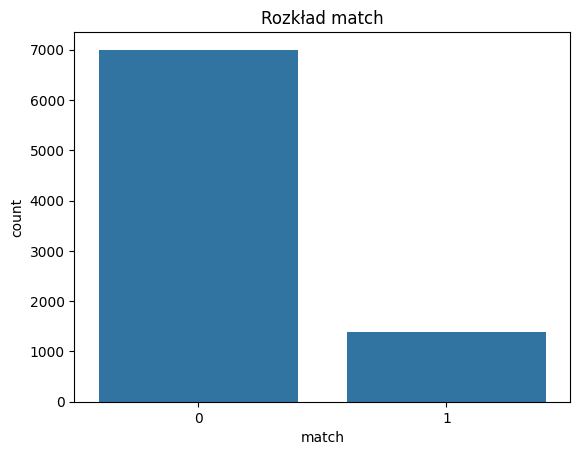

In [115]:
sns.countplot(data=df, x='match')
plt.title('Rozkład match') #bardzo niezbalansowane klasy

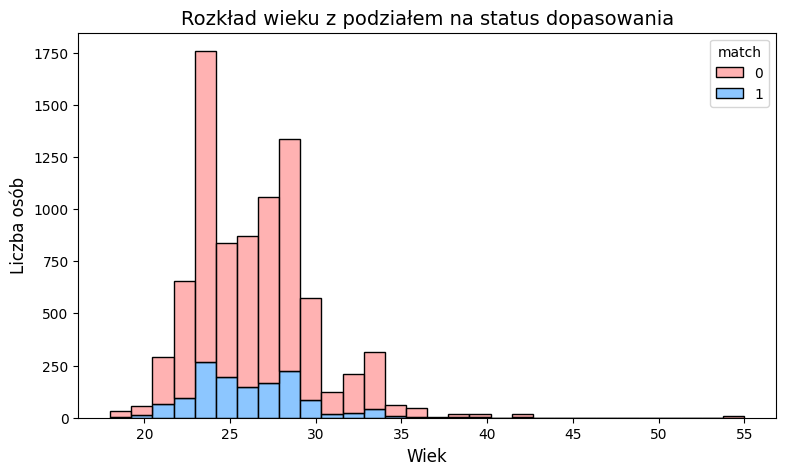

In [116]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', hue='match', multiple='stack', bins=30, palette=['#ff9999', '#66b3ff'])
plt.title('Rozkład wieku z podziałem na status dopasowania', fontsize=14)
plt.xlabel('Wiek', fontsize=12)
plt.ylabel('Liczba osób', fontsize=12)
plt.show()

In [118]:
#dodanie mapowania na poprawne nazwy kolumn, aby uniknąć później błędów
typo_correction = {
    'intellicence_important': 'intelligence_important',
    'ambtition_important': 'ambition_important',
    'd_intellicence_important': 'd_intelligence_important',
    'd_ambtition_important': 'd_ambition_important',
    'sinsere_o': 'sincere_o',
    'ambitous_o': 'ambitious_o',
    'd_sinsere_o': 'd_sincere_o',
    'd_ambitous_o': 'd_ambitious_o'
}

df = df.rename(columns=typo_correction, errors='ignore')

In [119]:
#przygotowanie danych

columns_to_drop = ['has_null', 'wave', 'd_d_age', 'd_importance_same_race', 'd_importance_same_religion',
                   'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence',
                   'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests',
                   'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o',
                   'd_shared_interests_o', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important',
                   'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
                   'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important',
                   'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition',
                   'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner',
                   'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner',
                   'd_shared_interests_partner', 'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums',
                   'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv', 'd_theater', 'd_movies',
                   'd_concerts', 'd_music', 'd_shopping', 'd_yoga', 'd_interests_correlate',
                   'd_expected_happy_with_sd_people', 'd_expected_num_interested_in_me', 'd_expected_num_matches',
                   'd_like', 'd_guess_prob_liked', 'like', 'guess_prob_liked', 'decision', 'decision_o']

print("liczba kolumn do usunięcia: ", len(columns_to_drop))

liczba kolumn do usunięcia:  73


In [120]:
feature_columns = [col for col in df.columns if col not in columns_to_drop]

X = df[feature_columns].copy()
X = X.drop('match', axis=1)
y = df['match'].astype(int)

print(f"Features number: {X.shape[1]}")

Features number: 55


In [121]:
#dodanie id

individual_features = [
    'gender', 'age', 'race', 'field',
    'importance_same_race', 'importance_same_religion',
    'attractive_important', 'sincere_important', 'intellicence_important',
    'funny_important', 'ambtition_important', 'shared_interests_important',
    'attractive', 'sincere', 'intelligence', 'funny', 'ambition',
    'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking',
    'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts',
    'music', 'shopping', 'yoga',
    'expected_happy_with_sd_people', 'expected_num_matches',
]
existing_features = [col for col in individual_features if col in df.columns]
user_id = df.groupby(existing_features, sort=False, dropna=False).ngroup()

print(f'Number of unique users: {user_id.nunique()}')


Number of unique users: 550


In [122]:
#podział danych na treningowe i testowe
N = 5 #określona stała liczba prób
train_indices = []
test_indices = []

user_counts = user_id.value_counts()

valid_users = user_counts[user_counts >= N].index
invalid_users = user_counts[user_counts < N].index

np.random.seed(42)

for uid in valid_users:
    user_idx = user_id[user_id == uid].index.to_numpy()
    test_idx = np.random.choice(user_idx, size=N, replace=False)
    train_idx = np.setdiff1d(user_idx, test_idx) #np.setdiff1d - wyznacza różnicę dwóch zbiorów.
    #Zwraca unikalne elementy znajdujące się w pierwszej tablicy, których nie ma w drugiej tablicy,
    #a wynik jest zawsze automatycznie sortowany.
    test_indices.extend(test_idx)
    train_indices.extend(train_idx)

for uid in invalid_users:
    user_idx = user_id[user_id == uid].index.to_numpy()
    train_indices.extend(user_idx)

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()

y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

user_id_train = user_id.loc[train_indices]
user_id_test = user_id.loc[test_indices]

print(f"Zbiór uczący (wiersze): {len(X_train)}")
print(f"Zbiór testowy (wiersze): {len(X_test)}")

test_counts = user_id_test.value_counts()
print(f"Czy każdy w teście ma dokładnie {N} prób? -> {all(test_counts == N)}")

Zbiór uczący (wiersze): 5628
Zbiór testowy (wiersze): 2750
Czy każdy w teście ma dokładnie 5 prób? -> True


In [123]:
#dodatkowe cechy

def add_feature(X_data):
  X_new = X_data.copy()
  #różnica między szukaną atrakcyjnością u partnera a własną samooceną
  if 'attractive_important' in X_new.columns and 'attractive' in X_new.columns:
        X_new['attr_expectation_gap'] = X_new['attractive_important'] - X_new['attractive']
  #analogicznie dla inteligencji
  if 'intelligence_important' in X_new.columns and 'intelligence' in X_new.columns:
        X_new['intell_expectation_gap'] = X_new['intelligence_important'] - X_new['intelligence']

  return X_new

X_train_plus = add_feature(X_train)
X_test_plus = add_feature(X_test)

print(X_train_plus['intell_expectation_gap'])

829      NaN
830      NaN
831      NaN
832      NaN
833      NaN
        ... 
6861     8.0
6853     4.0
6848    11.0
7387    10.0
7373    11.0
Name: intell_expectation_gap, Length: 5628, dtype: float64


In [124]:
#trening modelu

categorical_cols = ['gender', 'race', 'race_o', 'field']
numerical_cols = [col for col in X_train_plus.columns if col not in categorical_cols]
for col in numerical_cols:
    X_train_plus[col] = pd.to_numeric(X_train_plus[col], errors='coerce')
    X_test_plus[col] = pd.to_numeric(X_test_plus[col], errors='coerce')

for col in categorical_cols:
    unique_count = X_train_plus[col].nunique()
    print(f"\nKolumna: '{col}' | Liczba unikalnych wartości: {unique_count}")

print()

print(f"{len(categorical_cols)} kolumn tekstowych: {categorical_cols}")
print(f"{len(numerical_cols)} kolumn liczbowych.")


Kolumna: 'gender' | Liczba unikalnych wartości: 2

Kolumna: 'race' | Liczba unikalnych wartości: 6

Kolumna: 'race_o' | Liczba unikalnych wartości: 6

Kolumna: 'field' | Liczba unikalnych wartości: 258

4 kolumn tekstowych: ['gender', 'race', 'race_o', 'field']
53 kolumn liczbowych.


In [125]:

print(f"{len(categorical_cols)} kolumn tekstowych: {categorical_cols}")
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='infrequent_if_exist',
        sparse_output=False,
        max_categories=15 #bo 258 różnych kolumn to za dużo
    ))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

X_train_ready = preprocessor.fit_transform(X_train_plus)
X_test_ready = preprocessor.transform(X_test_plus)



4 kolumn tekstowych: ['gender', 'race', 'race_o', 'field']


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['d_sincere_o' 'd_ambitious_o' 'd_intelligence_important'
 'd_ambition_important']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['d_sincere_o' 'd_ambitious_o' 'd_intelligence_important'
 'd_ambition_important']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [126]:
#predykator większościowy - model zawsze przewidzi klasę, która dominuje liczbowo w y_train (tu 0)

print("PREDYKTOR NAIWNY: WIĘKSZOŚCIOWY")
dummy_maj = DummyClassifier(strategy='most_frequent')
dummy_maj.fit(X_train_ready, y_train)
y_pred_maj = dummy_maj.predict(X_test_ready)

print(classification_report_imbalanced(y_test, y_pred_maj, zero_division=0))

PREDYKTOR NAIWNY: WIĘKSZOŚCIOWY
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      1.00      0.00      0.91      0.00      0.00      2309
          1       0.00      0.00      1.00      0.00      0.00      0.00       441

avg / total       0.70      0.84      0.16      0.77      0.00      0.00      2750



In [127]:
#Specificity [spe] - jak dobrze model potrafi odrzucać to, czego nie szukamy (czyli jak dobrze unika fałszywych alarmów)

#predykator losowy - zgadywanie z prawdopodobieństwem 50/50

print("\nPREDYKTOR NAIWNY: LOSOWY")
dummy_rand = DummyClassifier(strategy='uniform', random_state=42)
dummy_rand.fit(X_train_ready, y_train)
y_pred_rand = dummy_rand.predict(X_test_ready)

print(classification_report_imbalanced(y_test, y_pred_rand))


PREDYKTOR NAIWNY: LOSOWY
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.51      0.52      0.64      0.52      0.27      2309
          1       0.17      0.52      0.51      0.25      0.52      0.27       441

avg / total       0.74      0.51      0.52      0.57      0.52      0.27      2750



In [128]:
#regresja logistyczna i drzewo decyzyjne

print("\nMODEL BAZOWY: REGRESJA LOGISTYCZNA")
base_model_lr = LogisticRegression(max_iter=1000, random_state=42)
base_model_lr.fit(X_train_ready, y_train)
y_pred_base_lr = base_model_lr.predict(X_test_ready)

print(classification_report_imbalanced(y_test, y_pred_base_lr))

print("\nMODEL BAZOWY (2): DRZEWO DECYZYJNE")
base_model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
base_model_dt.fit(X_train_ready, y_train)
y_pred_base_dt = base_model_dt.predict(X_test_ready)

print(classification_report_imbalanced(y_test, y_pred_base_dt))


MODEL BAZOWY: REGRESJA LOGISTYCZNA
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.99      0.06      0.91      0.24      0.06      2309
          1       0.49      0.06      0.99      0.10      0.24      0.05       441

avg / total       0.79      0.84      0.21      0.78      0.24      0.06      2750


MODEL BAZOWY (2): DRZEWO DECYZYJNE
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.99      0.06      0.91      0.24      0.06      2309
          1       0.48      0.06      0.99      0.11      0.24      0.05       441

avg / total       0.79      0.84      0.21      0.78      0.24      0.06      2750



In [130]:
#techniki resamplingu danych:

#funkcja obrazująca TSN-e oraz losująca podzbiór danych
def plot_tsne(X, y, title, max_samples=1500):
    if len(X) > max_samples:
        np.random.seed(42)
        idx = np.random.choice(len(X), max_samples, replace=False)
        X_sub, y_sub = X[idx], y.iloc[idx] if hasattr(y, 'iloc') else y[idx]
    else:
        X_sub, y_sub = X, y

    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_sub)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=X_tsne[:, 0], y=X_tsne[:, 1],
        hue=y_sub, palette=['#3498db', '#e74c3c'],
        alpha=0.7, s=50
    )
    plt.title(title)
    plt.xlabel('t-SNE wymiar 1')
    plt.ylabel('t-SNE wymiar 2')
    plt.legend(title='Match', loc='best')
    plt.show()

Generowanie t-SNE dla danych oryginalnych...


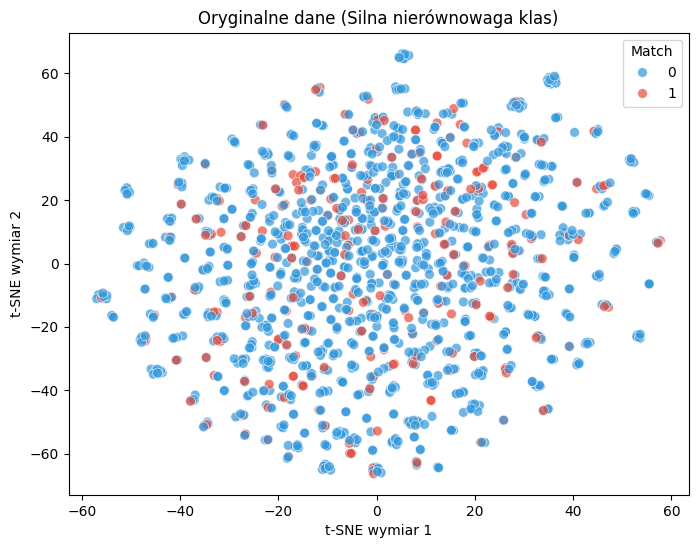

In [131]:
#zbiór danych przed resamplingiem
print("Generowanie t-SNE dla danych oryginalnych...")
plot_tsne(X_train_ready, y_train, "Oryginalne dane (Silnie niezbalansowane klasy)")


Rozkład klas po SMOTE: [4689 4689]


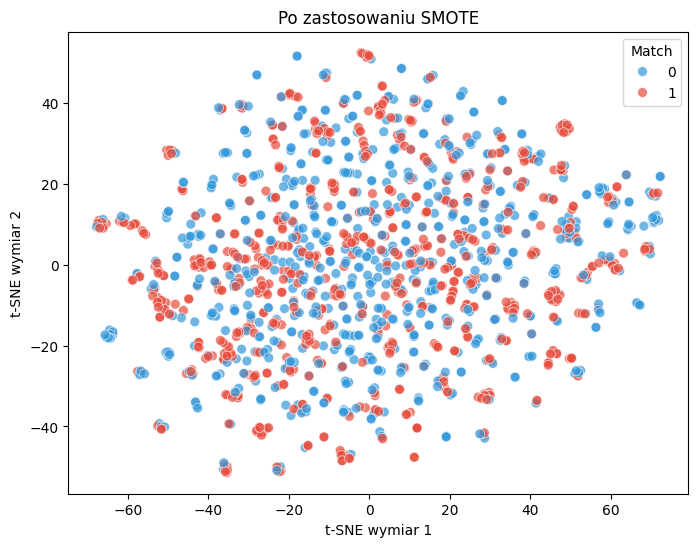

In [142]:
#użycie SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_ready, y_train)

print(f"\nRozkład klas po SMOTE: {np.bincount(y_smote)}")
plot_tsne(X_smote, y_smote, "Po zastosowaniu SMOTE")

#klasy idealnie zbalansowane, ale poprzez wygenerowanie przykładów pomiędzy już istniejącymi widzimy brak oddzielonych klastrów, to wprowadza chaos


Rozkład klas po RUS + SMOTE: [1878 1878]


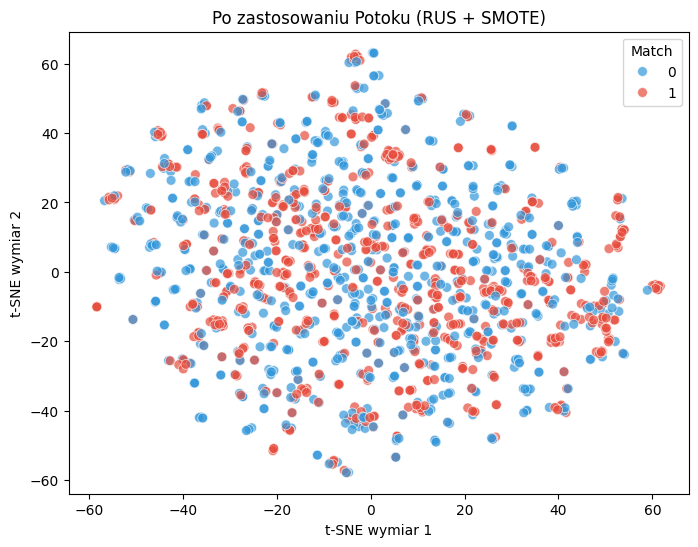

In [136]:
#potok łączący RandomUnderSampler oraz SMOTE
pipeline_rus_smote = ImbPipeline([
    ('rus', RandomUnderSampler(sampling_strategy=0.5, random_state=42)), #sampling_strategy=0.5 oznacza, że klasa mniejszościowa ma stanowić 50% klasy większościowej
    ('smote', SMOTE(sampling_strategy='auto', random_state=42))
])

X_pipe, y_pipe = pipeline_rus_smote.fit_resample(X_train_ready, y_train)
print(f"\nRozkład klas po RUS + SMOTE: {np.bincount(y_pipe)}")
plot_tsne(X_pipe, y_pipe, "Po zastosowaniu Potoku (RUS + SMOTE)")


Rozkład klas po SMOTE+ENN: [2781 4264]


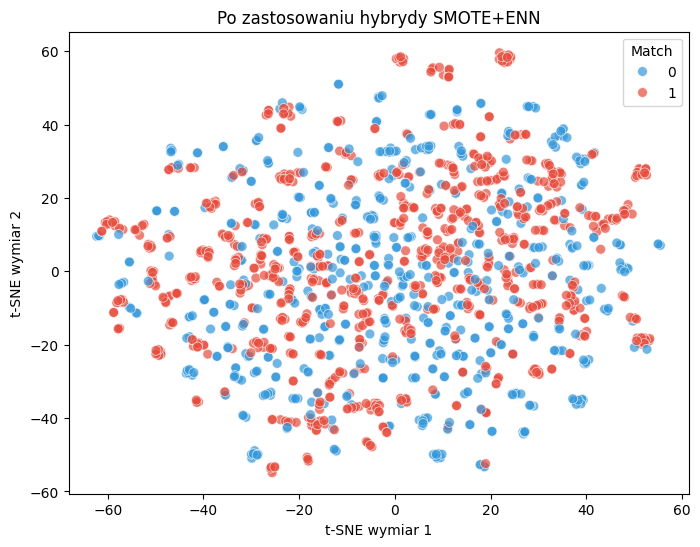

In [137]:
#metoda hybrydowa SMOTE+ENN
smote_enn = SMOTEENN(random_state=42)
X_smenn, y_smenn = smote_enn.fit_resample(X_train_ready, y_train)

print(f"\nRozkład klas po SMOTE+ENN: {np.bincount(y_smenn)}")
plot_tsne(X_smenn, y_smenn, "Po zastosowaniu hybrydy SMOTE+ENN")

In [140]:
#modele ensemble

print("RandomForestClassifier (class_weight='balanced')")
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train_ready, y_train)
y_pred_rf = rf_balanced.predict(X_test_ready)
print(classification_report_imbalanced(y_test, y_pred_rf))

print("\nBalancedRandomForestClassifier")
brf = BalancedRandomForestClassifier(sampling_strategy='auto', replacement=False, random_state=42)
brf.fit(X_train_ready, y_train)
y_pred_brf = brf.predict(X_test_ready)
print(classification_report_imbalanced(y_test, y_pred_brf))

RandomForestClassifier (class_weight='balanced')
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.99      0.06      0.91      0.24      0.06      2309
          1       0.50      0.06      0.99      0.11      0.24      0.05       441

avg / total       0.79      0.84      0.21      0.78      0.24      0.06      2750


BalancedRandomForestClassifier
                   pre       rec       spe        f1       geo       iba       sup

          0       0.90      0.68      0.60      0.77      0.64      0.41      2309
          1       0.26      0.60      0.68      0.37      0.64      0.40       441

avg / total       0.80      0.66      0.61      0.71      0.64      0.41      2750



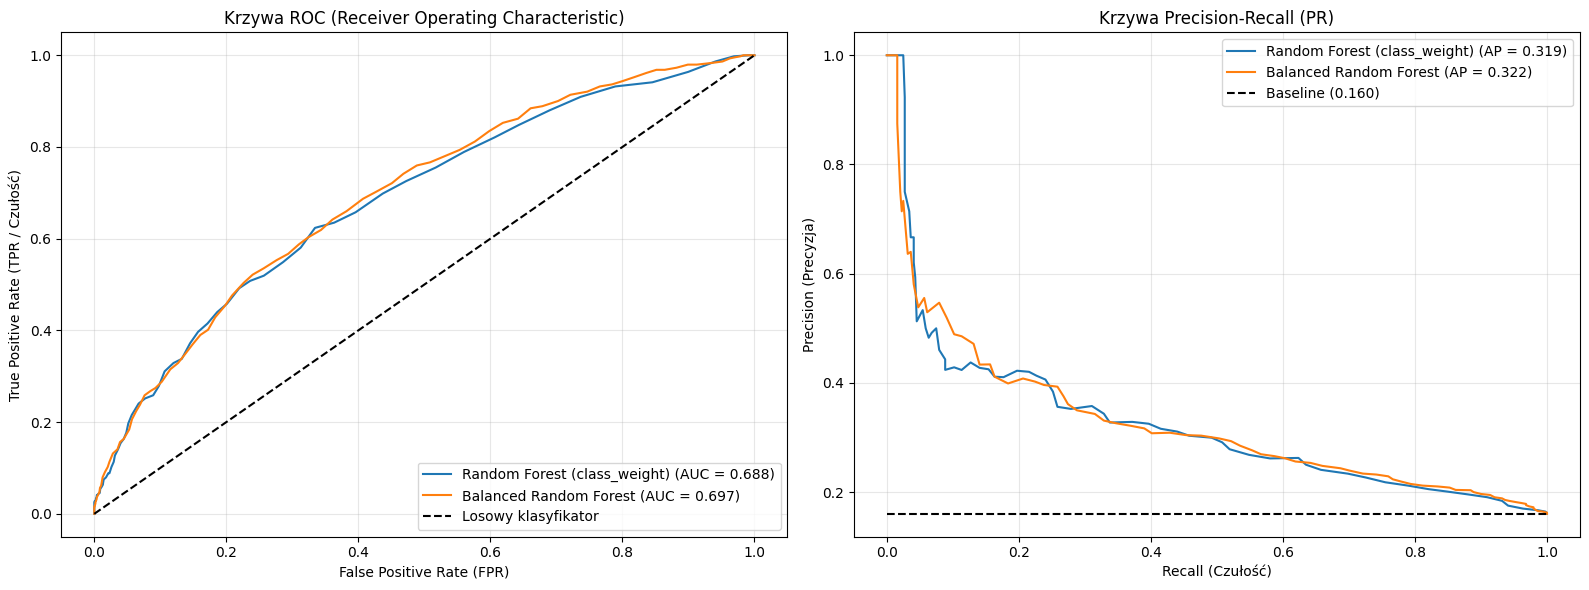

In [141]:
y_probs_rf = rf_balanced.predict_proba(X_test_ready)[:, 1]
y_probs_brf = brf.predict_proba(X_test_ready)[:, 1]

models_probs = {
    "Random Forest (class_weight)": y_probs_rf,
    "Balanced Random Forest": y_probs_brf
}

#krzywe ROC oraz Precision-Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', label='Losowy klasyfikator')
ax1.set_title('Krzywa ROC (Receiver Operating Characteristic)')
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR / Czułość)')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax2.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

baseline = sum(y_test) / len(y_test)
ax2.plot([0, 1], [baseline, baseline], 'k--', label=f'Baseline ({baseline:.3f})')
ax2.set_title('Krzywa Precision-Recall (PR)')
ax2.set_xlabel('Recall (Czułość)')
ax2.set_ylabel('Precision (Precyzja)')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Zadanie 2

In [143]:
y_probs = y_probs_brf
y_true = y_test.values if hasattr(y_test, 'values') else y_test

In [144]:
sorted_indices = np.argsort(y_probs)[::-1]
y_true_sorted = y_true[sorted_indices]
y_probs_sorted = y_probs[sorted_indices]

In [145]:
#funkcja do obliczenia Percyzji dla danego k
def precision_at_k(y_true_sorted, k=10):
    top_k = y_true_sorted[:k]
    return sum(top_k) / k

print(f"Precision@10 (dla 10 najpewniejszych rekomendacji): {precision_at_k(y_true_sorted, 10):.2f}")
print(f"Precision@50 (dla 50 najpewniejszych rekomendacji): {precision_at_k(y_true_sorted, 50):.2f}")

Precision@10 (dla 10 najpewniejszych rekomendacji): 0.80
Precision@50 (dla 50 najpewniejszych rekomendacji): 0.52


In [146]:
#obliczanie MRR
first_match_rank = np.where(y_true_sorted == 1)[0][0] + 1
mrr = 1.0 / first_match_rank
print(f"Globalny Reciprocal Rank: {mrr:.4f} (Pierwszy prawdziwy match na pozycji {first_match_rank})")

Globalny Reciprocal Rank: 1.0000 (Pierwszy prawdziwy match na pozycji 1)


In [147]:
#model romantyczny

threshold_romantic = 0.20 #polecamy osoby, które mają małą, ale jakąś szansę, nie liczymy się z kosztami
y_pred_romantic = (y_probs >= threshold_romantic).astype(int)

In [151]:
#model biznesowy

profit_TP = 50   #trafne polecenie
cost_FP = -15    #chybione polecenie
cost_FN = -2     #przeoczenie dopasowania
profit_TN = 1    #trafne niepolecenie

def calculate_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_profit = (tp * profit_TP) + (fp * cost_FP) + (fn * cost_FN) + (tn * profit_TN)
    return total_profit, tn, fp, fn, tp

thresholds = np.linspace(0.1, 0.9, 100)
best_profit = -np.inf
best_threshold_business = 0.5

for t in thresholds:
    temp_preds = (y_probs >= t).astype(int)
    profit, _, _, _, _ = calculate_profit(y_true, temp_preds)
    if profit > best_profit:
        best_profit = profit
        best_threshold_business = t

y_pred_business = (y_probs >= best_threshold_business).astype(int)
print(f"Znaleziony optymalny próg biznesowy: {best_threshold_business:.2f}")


Znaleziony optymalny próg biznesowy: 0.58


In [153]:
#porównanie wyników

def evaluate_model(name, y_true, y_pred):
    profit, tn, fp, fn, tp = calculate_profit(y_true, y_pred)
    return {
        "Model": name,
        "Threshold": f"{1 if name == 'Baseline' else (threshold_romantic if name == 'Romantyczny' else best_threshold_business):.2f}",
        "Recall": f"{recall_score(y_true, y_pred):.2f}",
        "Precision": f"{precision_score(y_true, y_pred):.2f}",
        "F1-Score": f"{f1_score(y_true, y_pred):.2f}",
        "Zysk (Profit)": profit,
        "TP (Sukcesy)": tp,
        "FP (Fałszywe Alarmy)": fp
    }

results = [
    evaluate_model("Romantyczny", y_true, y_pred_romantic),
    evaluate_model("Biznesowy", y_true, y_pred_business)
]

df_results = pd.DataFrame(results)
print("\nPorównanie Strategii")
print(df_results.to_string(index=False))


Porównanie Strategii
      Model Threshold Recall Precision F1-Score  Zysk (Profit)  TP (Sukcesy)  FP (Fałszywe Alarmy)
Romantyczny      0.20   0.98      0.17     0.29         -10297           433                  2140
  Biznesowy      0.58   0.48      0.30     0.37           4635           210                   482
